In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

In [47]:
def process():
    Day,RV,RVU = np.loadtxt('RCV.tbl.txt', skiprows=22, unpack=True)
    return(Day,RV,RVU)

In [48]:
Day, RV, RVU = process()

In [49]:
def f_model(x, a,b,c,d):
    return a * np.sin(( 2 * np.pi * (x - b) ) / c) + d

In [50]:
guess_params = [125, -170, 4500, 25]
#guess_params = [125, -170, 4500, 25]
best_params, _ = optimize.curve_fit(f_model, Day - Day[0], RV, p0=guess_params)
best_a = best_params[0]
best_b = best_params[1]
best_c = best_params[2]
best_d = best_params[3]
print(best_params)

[ 5.43926341e+01 -5.88293418e+02  4.77736070e+03  1.08236843e-01]


In [51]:
x_fit = np.linspace(min(Day - Day[0]), max(Day - Day[0]), len(Day))
y_fit = best_a * np.sin(2 * np.pi * (x_fit - best_b) / best_c) + best_d

In [52]:
y_residuals = RV - y_fit

In [53]:
def g_model(x, a,b,c,d):
    return a * np.sin(( 2 * np.pi * (x - b) ) / c) + d

guess_params = [125, -170, 2000, 10]
#guess_params = [125, -170, 4500, 25]
best_params, _ = optimize.curve_fit(g_model, Day - Day[0], y_residuals, p0=guess_params)
best_a = best_params[0]
best_b = best_params[1]
best_c = best_params[2]
best_d = best_params[3]
print(best_params)

y_fit_two = best_a * np.sin(2 * np.pi * (x_fit - best_b) / best_c) + best_d


[ -20.39457085 -782.71182809 2259.39564128  -11.00855506]


In [54]:
y_residuals_two = y_residuals - y_fit_two

In [59]:
def h_model(x, a,b,c,d):
    return a * np.sin(( 2 * np.pi * (x - b) ) / c) + d

guess_params = [500, 170, 4000, -10]
#guess_params = [125, -170, 4500, 25]
best_params, _ = optimize.curve_fit(h_model, Day - Day[0], y_residuals_two, p0=guess_params)
best_a = best_params[0]
best_b = best_params[1]
best_c = best_params[2]
best_d = best_params[3]
print(best_params)

y_fit_three = best_a * np.sin(2 * np.pi * (x_fit - best_b) / best_c) + best_d

[-7.51292884e+00  8.74633663e+02  3.15036052e+03 -1.29354210e+00]


In [56]:
y_residuals_three = y_residuals_two - y_fit_three

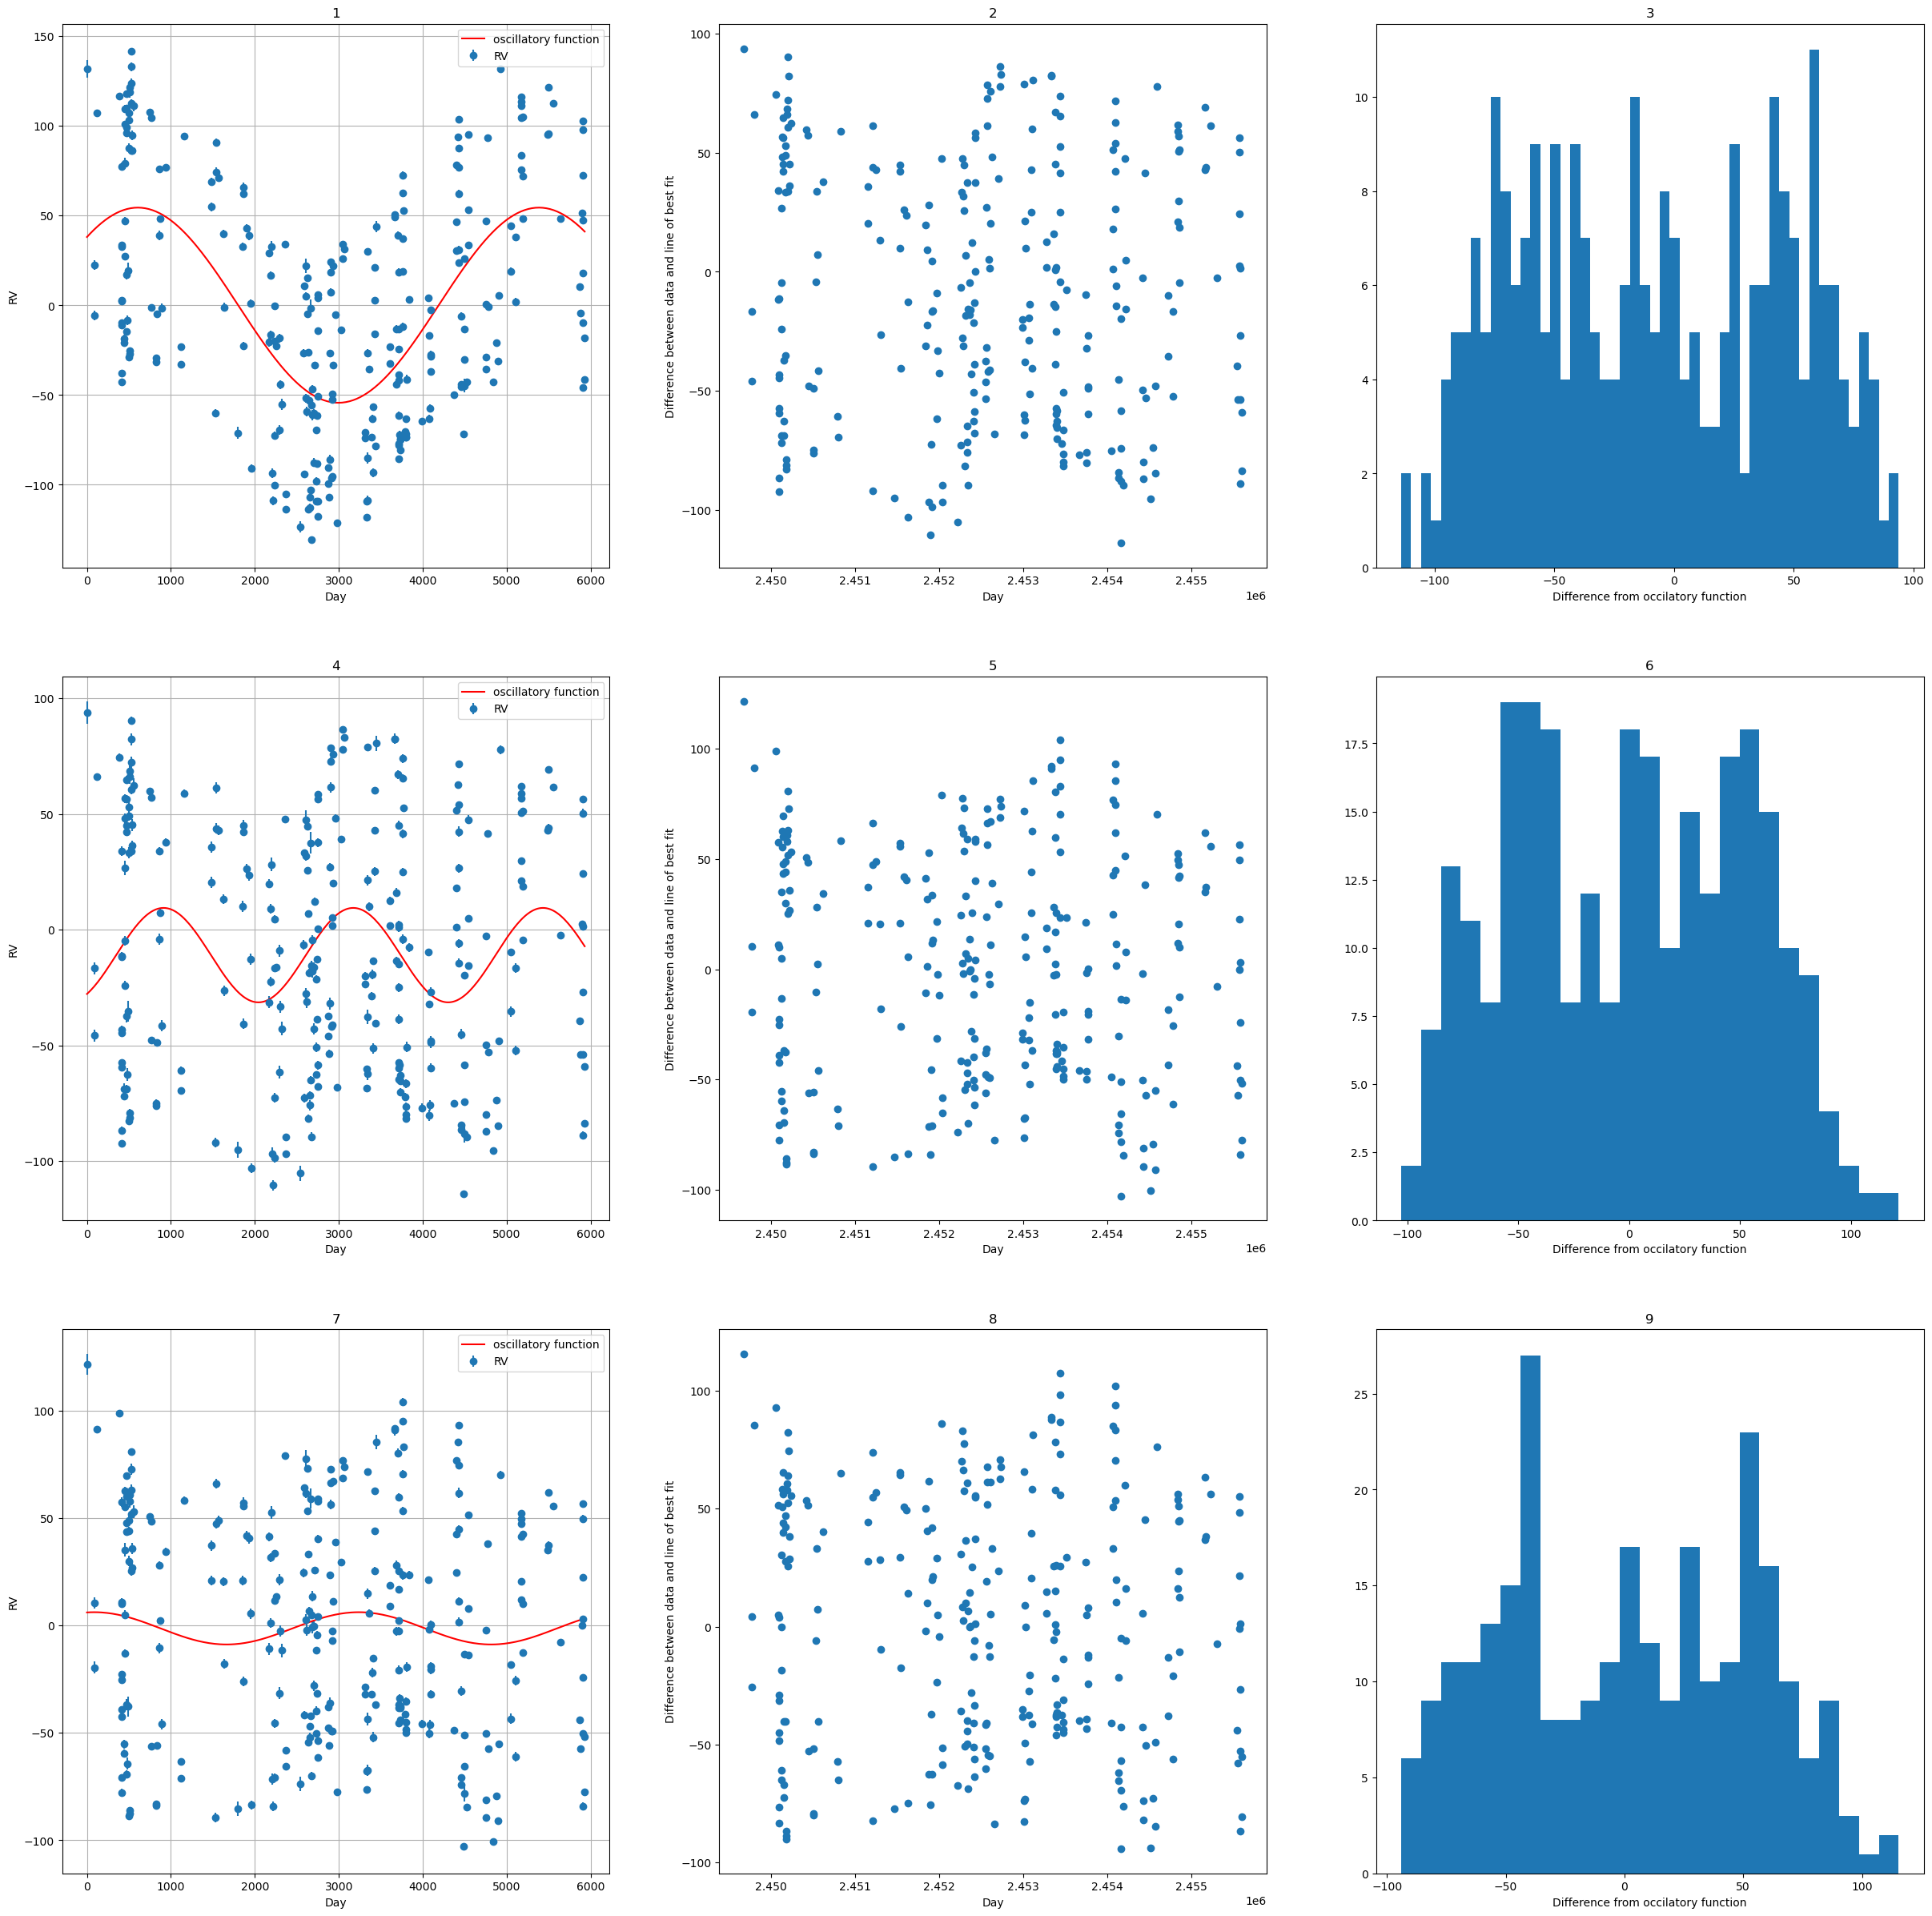

In [60]:
import matplotlib.pyplot as plt
import numpy as np
def chart():
    fig,ax = plt.subplots(3,3,figsize=(30,30))
    
    ax[0,0].set_title('1')
    ax[0,0].errorbar(Day - Day[0], RV, yerr=RVU, fmt='o', label='RV')
    ax[0,0].plot(x_fit, y_fit, 'r-', label='oscillatory function')
    ax[0,0].set_xlabel('Day')
    ax[0,0].set_ylabel('RV')
    #RV stands for radial velocity
    ax[0,0].legend()
    ax[0,0].grid(True)
    #ax[0,0].scatter(x,y)
    
    ax[0,1].set_title('2')
    ax[0,1].scatter(Day,y_residuals)
    ax[0,1].set_xlabel('Day')
    ax[0,1].set_ylabel('Difference between data and line of best fit')
    
    ax[0,2].hist(y_residuals,bins=50)
    ax[0,2].set_title('3')
    ax[0,2].set_xlabel('Difference from occilatory function')

    ax[1,0].set_title('4')
    ax[1,0].errorbar(Day - Day[0], y_residuals, yerr=RVU, fmt='o', label='RV')
    ax[1,0].plot(x_fit, y_fit_two, 'r-', label='oscillatory function')
    ax[1,0].set_xlabel('Day')
    ax[1,0].set_ylabel('RV')
    #RV stands for radial velocity
    ax[1,0].legend()
    ax[1,0].grid(True)

    ax[1,1].set_title('5')
    ax[1,1].set_xlabel('Day')
    ax[1,1].set_ylabel('Difference between data and line of best fit')
    ax[1,1].scatter(Day,y_residuals_two)
    
    ax[1,2].hist(y_residuals_two,bins=25)
    ax[1,2].set_xlabel('Difference from occilatory function')
    ax[1,2].set_title('6')

    ax[2,0].errorbar(Day - Day[0], y_residuals_two, yerr=RVU, fmt='o', label='RV')
    ax[2,0].plot(x_fit, y_fit_three, 'r-', label='oscillatory function')
    ax[2,0].set_xlabel('Day')
    ax[2,0].set_ylabel('RV')
    #RV stands for radial velocity
    ax[2,0].legend()
    ax[2,0].grid(True)
    ax[2,0].set_title('7')

    ax[2,1].set_title('8')
    ax[2,1].set_xlabel('Day')
    ax[2,1].set_ylabel('Difference between data and line of best fit')
    ax[2,1].scatter(Day,y_residuals_three)
    
    ax[2,2].hist(y_residuals_three,bins=25)
    ax[2,2].set_title('9')
    ax[2,2].set_xlabel('Difference from occilatory function')

chart()